IMPORT LIBRARIES

In [1]:
import pandas as pd
import re
import numpy as np
import time
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, log_loss
)

LOAD DATASET

In [2]:
file_path = "/content/data đồ án.xlsm"

df = pd.read_excel(file_path, engine="openpyxl")

df = df[["Comment", "Label", "Rate"]].dropna()
df["Label"] = df["Label"].astype(str).str.strip().str.upper()

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["Label"].value_counts())

Dataset shape: (31460, 3)

Label distribution:
Label
POS    20093
NEG     6669
NEU     4698
Name: count, dtype: int64


TEXT PREPROCESSING

In [3]:
def preprocess(text):
    text = str(text).lower()

    replacements = {
        " ko ": " không ",
        " k ": " không ",
        " kh ": " không ",
        " hok ": " không ",
        " kg ": " không ",
        " dc ": " được ",
        " đc ": " được ",
        " sp ": " sản phẩm ",
        " ok ": " tốt ",
        " oke ": " tốt ",
    }

    text = " " + text + " "
    for k, v in replacements.items():
        text = text.replace(k, v)

    text = re.sub(r"[^\w\sÀ-ỹ]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["Comment"].apply(preprocess)

print(df[["Comment", "clean_text", "Label"]].head())

                       Comment                  clean_text Label
0               Áo bao đẹp ạ!!                áo bao đẹp ạ   POS
1                  Tuyệt vời !                   tuyệt vời   POS
2   2day ao khong giong trong.    day ao khong giong trong   NEG
3  Mùi thơm,bôi lên da mềm da.  mùi thơm bôi lên da mềm da   POS
4            Vải đẹp, dày dặn.             vải đẹp dày dặn   POS


TRAIN / TEST SPLIT

In [4]:
X = df["clean_text"]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:",  X_test.shape[0])

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train size: 25168
Test size: 6292

Train label distribution:
Label
POS    16074
NEG     5335
NEU     3759
Name: count, dtype: int64

Test label distribution:
Label
POS    4019
NEG    1334
NEU     939
Name: count, dtype: int64


FEATURE ENGINEERING

In [5]:
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 3),
    max_features=30000,
    min_df=2,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=50000,
    min_df=2,
    sublinear_tf=True
)

features = FeatureUnion([
    ("word_tfidf", word_tfidf),
    ("char_tfidf", char_tfidf)
])

X_train_vec = features.fit_transform(X_train)
X_test_vec  = features.transform(X_test)

print("Feature matrix shape:", X_train_vec.shape)

Feature matrix shape: (25168, 45459)


BUILD RANDOM FOREST MODEL

TRAINING & LOSS/ACCURACY CURVE

Training done! n_estimators=500


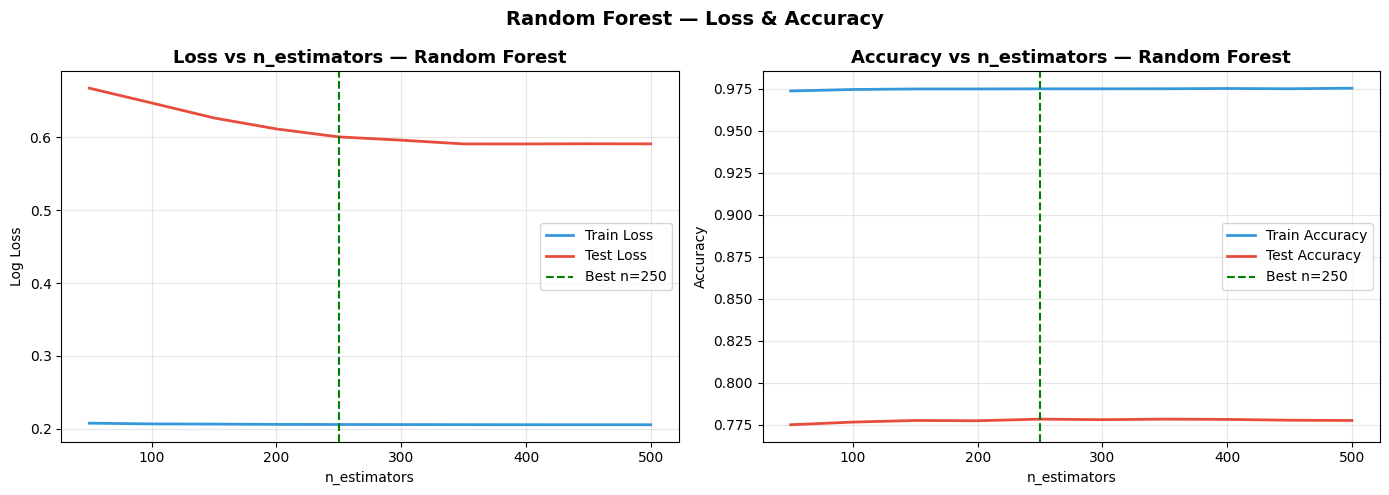

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
from sklearn.model_selection import cross_val_score

# Train model tốt nhất
best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    warm_start=False
)
best_rf.fit(X_train_vec, y_train)
joblib.dump(best_rf, "rf_best_model.pkl")
print("Training done! n_estimators=500")

# Vẽ Loss & Accuracy theo n_estimators (dùng staged predict)
CLASSES       = sorted(y_train.unique())
n_range       = list(range(50, 501, 50))
train_acc_list, test_acc_list   = [], []
train_loss_list, test_loss_list = [], []

for n in n_range:
    rf_tmp = RandomForestClassifier(
        n_estimators=n, max_depth=None,
        min_samples_split=4, min_samples_leaf=1,
        max_features="sqrt", class_weight="balanced",
        random_state=42, n_jobs=-1
    )
    rf_tmp.fit(X_train_vec, y_train)
    train_acc_list.append(accuracy_score(y_train, rf_tmp.predict(X_train_vec)))
    test_acc_list.append( accuracy_score(y_test,  rf_tmp.predict(X_test_vec)))
    train_loss_list.append(log_loss(y_train, rf_tmp.predict_proba(X_train_vec), labels=CLASSES))
    test_loss_list.append( log_loss(y_test,  rf_tmp.predict_proba(X_test_vec),  labels=CLASSES))

best_n = n_range[test_acc_list.index(max(test_acc_list))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_range, train_loss_list, label="Train Loss", color="#3498db", linewidth=2)
axes[0].plot(n_range, test_loss_list,  label="Test Loss",  color="#e74c3c", linewidth=2)
axes[0].axvline(best_n, color="green", linestyle="--", linewidth=1.5, label=f"Best n={best_n}")
axes[0].set_title("Loss vs n_estimators — Random Forest", fontsize=13, fontweight="bold")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("Log Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_range, train_acc_list, label="Train Accuracy", color="#3498db", linewidth=2)
axes[1].plot(n_range, test_acc_list,  label="Test Accuracy",  color="#e74c3c", linewidth=2)
axes[1].axvline(best_n, color="green", linestyle="--", linewidth=1.5, label=f"Best n={best_n}")
axes[1].set_title("Accuracy vs n_estimators — Random Forest", fontsize=13, fontweight="bold")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Random Forest — Loss & Accuracy", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("rf_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

# Lưu curve data
curve_data = {
    "n_range": n_range,
    "train_acc": train_acc_list, "test_acc": test_acc_list,
    "train_loss": train_loss_list, "test_loss": test_loss_list,
    "best_n": best_n
}
import json
with open("rf_curve_data.json", "w") as f:
    json.dump(curve_data, f, indent=2)


EVALUATION

In [7]:
best_rf = joblib.load("rf_best_model.pkl")
y_pred  = best_rf.predict(X_test_vec)

print("==== MODEL RANDOM FOREST ====")

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall    = recall_score(y_test, y_pred, average="macro")
f1        = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


==== MODEL RANDOM FOREST ====
Accuracy:  0.7777
Precision: 0.6478
Recall:    0.6492
F1 Score:  0.6431

Confusion Matrix:
[[1049  148  137]
 [ 322  251  366]
 [ 184  242 3593]]

Classification Report:
              precision    recall  f1-score   support

         NEG     0.6746    0.7864    0.7262      1334
         NEU     0.3916    0.2673    0.3177       939
         POS     0.8772    0.8940    0.8855      4019

    accuracy                         0.7777      6292
   macro avg     0.6478    0.6492    0.6431      6292
weighted avg     0.7618    0.7777    0.7670      6292



CONFUSION MATRIX VISUALIZATION

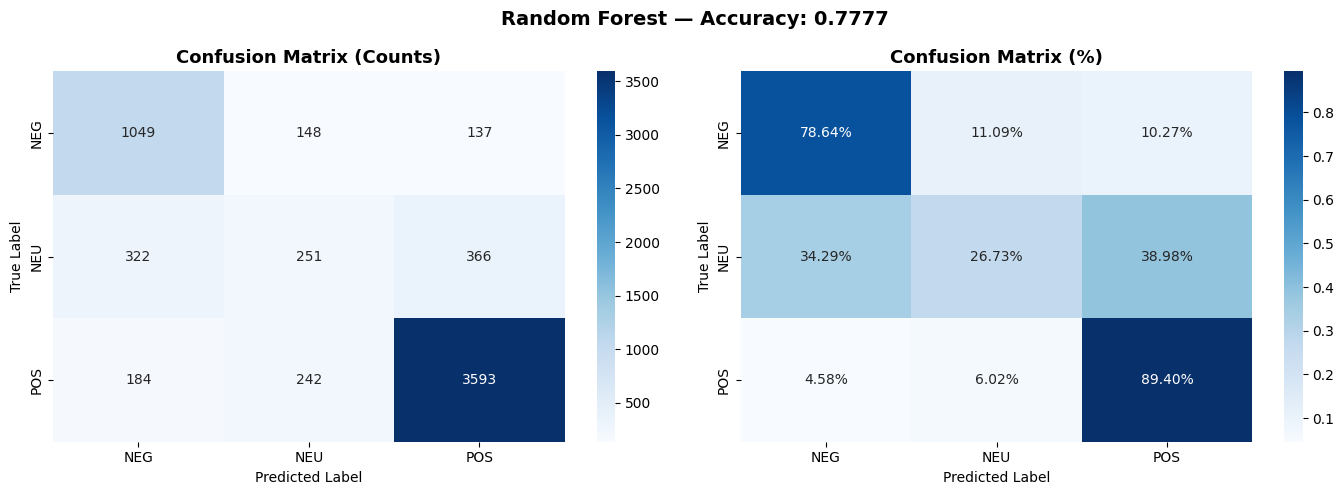

In [8]:
labels = sorted(y_test.unique())
cm     = confusion_matrix(y_test, y_pred, labels=labels)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_pct, annot=True, fmt=".2%", cmap="Blues", ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title("Confusion Matrix (%)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.suptitle(f"Random Forest — Accuracy: {accuracy:.4f}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

Calculate Params, Model Size, Inference Time, FPS

In [9]:
model_path    = "rf_best_model.pkl"
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

total_params = sum(
    tree.tree_.node_count for tree in best_rf.estimators_
)

start_time     = time.time()
_ = best_rf.predict(X_test_vec)
inference_time = time.time() - start_time
fps            = len(X_test) / inference_time

print("==== MODEL STATISTICS — RANDOM FOREST ====")
print(f"Total nodes (params): {total_params:,}")
print(f"Model size:           {model_size_mb:.2f} MB")
print(f"Inference time:       {inference_time:.4f} s ({len(X_test)} samples)")
print(f"FPS:                  {fps:.1f} samples/s")
print(f"Accuracy:             {accuracy:.4f}")
print(f"Precision (macro):    {precision:.4f}")
print(f"Recall (macro):       {recall:.4f}")
print(f"F1 (macro):           {f1:.4f}")

==== MODEL STATISTICS — RANDOM FOREST ====
Total nodes (params): 5,066,590
Model size:           425.40 MB
Inference time:       1.7943 s (6292 samples)
FPS:                  3506.6 samples/s
Accuracy:             0.7777
Precision (macro):    0.6478
Recall (macro):       0.6492
F1 (macro):           0.6431


In [10]:
# LƯU KẾT QUẢ CHO STREAMLIT
import json, inspect

OUTPUT_DIR = "streamlit_assets"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABELS = ["NEG", "NEU", "POS"]

# 1. Model + Feature pipeline
joblib.dump(best_rf,  f"{OUTPUT_DIR}/rf_model.pkl")
joblib.dump(features, f"{OUTPUT_DIR}/rf_features.pkl")

# 2. Metrics JSON
report_dict = classification_report(y_test, y_pred, output_dict=True)

metrics = {
    "model_name":    "Random Forest",
    "n_estimators":  int(best_rf.n_estimators),
    "accuracy":      round(accuracy,  4),
    "precision":     round(precision, 4),
    "recall":        round(recall,    4),
    "f1_macro":      round(f1,        4),
    "f1_weighted":   round(f1_score(y_test, y_pred, average="weighted"), 4),
    "total_nodes":   total_params,
    "model_size_mb": round(model_size_mb, 2),
    "fps":           round(fps, 2),
    "inference_ms":  round(inference_time / len(X_test) * 1000, 4),
    "per_class": {
        label: {
            "precision": round(report_dict[label]["precision"], 4),
            "recall":    round(report_dict[label]["recall"],    4),
            "f1":        round(report_dict[label]["f1-score"],  4),
            "support":   int(report_dict[label]["support"])
        }
        for label in LABELS if label in report_dict
    }
}

with open(f"{OUTPUT_DIR}/metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

# 3. Curve data
import shutil
if os.path.exists("rf_curve_data.json"):
    shutil.copy("rf_curve_data.json", f"{OUTPUT_DIR}/loss_acc_curve.json")
if os.path.exists("rf_training_history.png"):
    shutil.copy("rf_training_history.png", f"{OUTPUT_DIR}/loss_acc_curve.png")

# 4. Confusion matrix số + PNG
cm_save = confusion_matrix(y_test, y_pred, labels=LABELS)
np.save(f"{OUTPUT_DIR}/confusion_matrix.npy", cm_save)
if os.path.exists("rf_confusion_matrix.png"):
    shutil.copy("rf_confusion_matrix.png", f"{OUTPUT_DIR}/confusion_matrix.png")

# 5. Preprocess function
preprocess_src = inspect.getsource(preprocess)
with open(f"{OUTPUT_DIR}/preprocess.py", "w", encoding="utf-8") as f:
    f.write("import re\n\n")
    f.write(preprocess_src)

print("=== STREAMLIT ASSETS SAVED ===")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f"{OUTPUT_DIR}/{fname}")
    print(f"  {fname:<35} {size/1024:.1f} KB")


=== STREAMLIT ASSETS SAVED ===
  confusion_matrix.npy                0.2 KB
  confusion_matrix.png                86.8 KB
  loss_acc_curve.json                 1.2 KB
  loss_acc_curve.png                  92.5 KB
  metrics.json                        0.6 KB
  preprocess.py                       0.7 KB
  rf_features.pkl                     1764.2 KB
  rf_model.pkl                        435611.1 KB
